# M08 stability evaluation: seed123 vs seed124

This notebook compares two independent trainings of the same residual dilated M08 architecture:

- **M08 seed123**
- **M08 seed124**

The dataset, split, architecture, and hyperparameters must remain fixed. Only the training seed changes.

The objective is to evaluate optimization-level stability, not to select a statistically significant winner between seeds.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_ROOT = DATA_ROOT / "results"
CHECKPOINT_ROOT = DATA_ROOT / "models" / "checkpoints"
PROCESSED_ROOT = DATA_ROOT / "processed"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
DATASET_RESULTS_ROOT = RESULTS_ROOT / DATASET_ID
DATASET_CHECKPOINT_ROOT = CHECKPOINT_ROOT / DATASET_ID
DATASET_PROCESSED_ROOT = PROCESSED_ROOT / DATASET_ID

LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
LABEL_UNITS = {
    "chirp_mass": r"$M_\odot$",
    "total_mass": r"$M_\odot$",
    "chi_eff": "dimensionless",
}
SPLITS = ["val", "cal", "test"]

print(DATASET_RESULTS_ROOT, DATASET_RESULTS_ROOT.exists())
print(DATASET_CHECKPOINT_ROOT, DATASET_CHECKPOINT_ROOT.exists())

/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
/data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True


## Resolve files

The seed124 filenames contain `M08a_resdilated`, which is only a naming inconsistency. The checkpoint metadata is checked later to confirm `dilations=[1,2,4]`.

In [19]:
def resolve_file(root, patterns, description):
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}. Patterns: {patterns}"
        )

    print(f"\n{description}:")
    for path in matches:
        print(" ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


RUNS = {
    "seed123": {
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",
        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz",
        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt",
        ],
    },
    "seed124": {
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_M08_resdilated_emb64_d124_MSELoss_seed124_val_cal_test_predictions_embeddings.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilated*resdilated*d124*seed124*val_cal_test*predictions_embeddings.npz",
        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_M08_resdilated_emb64_d124_MSELoss_seed124_history.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilated*resdilated*d124*seed124*history.npz",
        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_M08_resdilated_emb64_d124_MSELoss_seed124_checkpoint.pt",
            f"{DATASET_ID}_SimpleCNN_ResidualDilated*resdilated*d124*seed124*checkpoint.pt",
        ],
    },
}

for run_id, run in RUNS.items():
    run["prediction_path"] = resolve_file(
        DATASET_RESULTS_ROOT, run["prediction_patterns"], f"{run_id} predictions"
    )
    run["history_path"] = resolve_file(
        DATASET_RESULTS_ROOT, run["history_patterns"], f"{run_id} history"
    )
    run["checkpoint_path"] = resolve_file(
        DATASET_CHECKPOINT_ROOT, run["checkpoint_patterns"], f"{run_id} checkpoint"
    )


seed123 predictions:
  bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz

seed123 history:
  bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz

seed123 checkpoint:
  bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt

seed124 predictions:
  bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M08_resdilated_emb64_d124_MSELos

## Load label statistics and predictions

In [20]:
LABEL_STATS_PATH = resolve_file(
    DATASET_PROCESSED_ROOT,
    [
        f"{DATASET_ID}_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
        f"{DATASET_ID}*label_stats*seed123.npz",
    ],
    "label statistics",
)

with np.load(LABEL_STATS_PATH) as stats:
    y_mean = np.asarray(stats["y_mean"], dtype=float)
    y_std = np.asarray(stats["y_std"], dtype=float)

def load_npz(path):
    with np.load(path, allow_pickle=True) as data:
        out = {key: np.asarray(data[key]) for key in data.files}
    print(path.name)
    for key in sorted(out):
        print(f"  {key:24s} {out[key].shape}")
    return out

RAW = {run_id: load_npz(run["prediction_path"]) for run_id, run in RUNS.items()}


label statistics:
  bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
  available_splits         (3,)
  checkpoint_file          ()
  dataset_path             ()
  emb_cal                  (30000, 64)
  emb_test                 (30000, 64)
  emb_val                  (40000, 64)
  idx_cal                  (30000,)
  idx_test                 (30000,)
  idx_val                  (40000,)
  label_names              (3,)
  label_stats_path         ()
  model_config             ()
  pred_cal                 (30000, 3)
  pred_test                (30000, 3)
  pred_val                 (40000, 3)
  split_path               ()
  y_cal                  

## Align by physical HDF5 indices

In [21]:
def align_split(raw_by_run, split):
    common_idx = None

    for data in raw_by_run.values():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        common_idx = idx if common_idx is None else np.intersect1d(common_idx, idx)

    common_idx = np.sort(common_idx)
    aligned = {}

    for run_id, data in raw_by_run.items():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        order = np.argsort(idx)
        idx_sorted = idx[order]
        pos = np.searchsorted(idx_sorted, common_idx)

        assert np.array_equal(idx_sorted[pos], common_idx)

        aligned[run_id] = {
            "idx": common_idx,
            "pred": np.asarray(data[f"pred_{split}"])[order][pos],
            "y": np.asarray(data[f"y_{split}"])[order][pos],
            "emb": np.asarray(data[f"emb_{split}"])[order][pos],
        }

    assert np.allclose(
        aligned["seed123"]["y"],
        aligned["seed124"]["y"],
        rtol=1e-5,
        atol=1e-5,
    )
    return aligned

ALIGNED = {split: align_split(RAW, split) for split in SPLITS}

for split in SPLITS:
    print(split, len(ALIGNED[split]["seed123"]["idx"]))

val 40000
cal 30000
test 30000


## Core regression metrics

In [23]:
def inverse_standardize(y):
    return y * y_std + y_mean

def regression_metrics(y_true, y_pred, run_id, split, space):
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_error, axis=0)
    bias = np.mean(residual, axis=0)
    medae = np.median(abs_error, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1 - ss_res / ss_tot

    rows = []
    for j, label in enumerate(LABEL_NAMES):
        rows.append({
            "run_id": run_id,
            "split": split,
            "space": space,
            "label": label,
            "MSE": mse[j],
            "RMSE": rmse[j],
            "MAE": mae[j],
            "bias": bias[j],
            "median_abs_error": medae[j],
            "residual_std": residual_std[j],
            "R2": r2[j],
        })
    return rows

rows = []

for split in SPLITS:
    y_std_true = ALIGNED[split]["seed123"]["y"]
    y_phys_true = inverse_standardize(y_std_true)

    for run_id in RUNS:
        pred_std = ALIGNED[split][run_id]["pred"]
        pred_phys = inverse_standardize(pred_std)

        rows += regression_metrics(
            y_std_true, pred_std, run_id, split, "standardized"
        )
        rows += regression_metrics(
            y_phys_true, pred_phys, run_id, split, "physical"
        )

metrics_df = pd.DataFrame(rows)

global_metrics_df = (
    metrics_df
    .groupby(["run_id", "split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(global_metrics_df.query("space == 'standardized'"))
display(
    metrics_df.query("split == 'test' and space == 'standardized'")
    .sort_values(["label", "run_id"])
)

,run_id,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
1,seed123,cal,standardized,0.115611,0.333401,0.243953,0.884359
3,seed123,test,standardized,0.116352,0.334414,0.244785,0.883717
5,seed123,val,standardized,0.116115,0.334060,0.244682,0.883949
7,seed124,cal,standardized,0.112905,0.329767,0.238550,0.887070
9,seed124,test,standardized,0.112170,0.328765,0.237502,0.887902
11,seed124,val,standardized,0.113727,0.330779,0.238676,0.886343


,run_id,split,space,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
26,seed123,test,standardized,chi_eff,0.182919,0.427691,0.321956,-0.011796,0.251846,0.427528,0.816637
32,seed124,test,standardized,chi_eff,0.174001,0.417135,0.312198,0.001372,0.243411,0.417133,0.825577
24,seed123,test,standardized,chirp_mass,0.092243,0.303716,0.211312,-0.007336,0.141675,0.303627,0.908286
30,seed124,test,standardized,chirp_mass,0.090571,0.300950,0.204765,-0.043434,0.132121,0.297799,0.909949
25,seed123,test,standardized,total_mass,0.073894,0.271834,0.201088,-0.017916,0.152958,0.271244,0.926229
31,seed124,test,standardized,total_mass,0.071937,0.268211,0.195542,-0.043020,0.143920,0.264738,0.928182


## Seed-to-seed differences

In [24]:
test_std = metrics_df.query("split == 'test' and space == 'standardized'")
pivot = test_std.pivot(index="label", columns="run_id")

difference_rows = []

for label in LABEL_NAMES:
    row = {"label": label}
    for metric in ["MSE", "RMSE", "MAE"]:
        a = float(pivot.loc[label, (metric, "seed123")])
        b = float(pivot.loc[label, (metric, "seed124")])
        row[f"{metric}_seed123"] = a
        row[f"{metric}_seed124"] = b
        row[f"{metric}_difference_pct"] = 100 * (b - a) / a

    row["R2_difference"] = (
        float(pivot.loc[label, ("R2", "seed124")])
        - float(pivot.loc[label, ("R2", "seed123")])
    )
    difference_rows.append(row)

seed_difference_df = pd.DataFrame(difference_rows)
display(seed_difference_df)

global_test = (
    global_metrics_df
    .query("split == 'test' and space == 'standardized'")
    .set_index("run_id")
)

global_difference_df = pd.DataFrame([{
    "global_MSE_seed123": global_test.loc["seed123", "global_MSE"],
    "global_MSE_seed124": global_test.loc["seed124", "global_MSE"],
    "global_MSE_difference_pct": 100 * (
        global_test.loc["seed124", "global_MSE"]
        - global_test.loc["seed123", "global_MSE"]
    ) / global_test.loc["seed123", "global_MSE"],
    "global_MAE_seed123": global_test.loc["seed123", "global_MAE"],
    "global_MAE_seed124": global_test.loc["seed124", "global_MAE"],
    "global_MAE_difference_pct": 100 * (
        global_test.loc["seed124", "global_MAE"]
        - global_test.loc["seed123", "global_MAE"]
    ) / global_test.loc["seed123", "global_MAE"],
}])

display(global_difference_df)

,label,MSE_seed123,MSE_seed124,MSE_difference_pct,RMSE_seed123,RMSE_seed124,RMSE_difference_pct,MAE_seed123,MAE_seed124,MAE_difference_pct,R2_difference
0,chirp_mass,0.092243,0.090571,-1.813168,0.303716,0.300950,-0.910733,0.211312,0.204765,-3.098654,0.001663
1,total_mass,0.073894,0.071937,-2.647803,0.271834,0.268211,-1.332780,0.201088,0.195542,-2.757699,0.001953
2,chi_eff,0.182919,0.174001,-4.875363,0.427691,0.417135,-2.468141,0.321956,0.312198,-3.030991,0.008940


,global_MSE_seed123,global_MSE_seed124,global_MSE_difference_pct,global_MAE_seed123,global_MAE_seed124,global_MAE_difference_pct
0,0.116352,0.112170,-3.594568,0.244785,0.237502,-2.975626


## Slopes and prediction contraction

In [25]:
def slope_metrics(y_true, y_pred, run_id, split):
    rows = []
    for j, label in enumerate(LABEL_NAMES):
        true = y_true[:, j]
        pred = y_pred[:, j]
        slope, intercept = np.polyfit(true, pred, 1)
        q01_t, q99_t = np.quantile(true, [0.01, 0.99])
        q01_p, q99_p = np.quantile(pred, [0.01, 0.99])

        rows.append({
            "run_id": run_id,
            "split": split,
            "label": label,
            "slope": slope,
            "intercept": intercept,
            "correlation": np.corrcoef(true, pred)[0, 1],
            "std_ratio_pred_over_true": np.std(pred) / np.std(true),
            "q01_q99_ratio_pred_over_true": (
                (q99_p - q01_p) / (q99_t - q01_t)
            ),
        })
    return rows

slope_rows = []

for split in SPLITS:
    y_true = ALIGNED[split]["seed123"]["y"]
    for run_id in RUNS:
        slope_rows += slope_metrics(
            y_true,
            ALIGNED[split][run_id]["pred"],
            run_id,
            split,
        )

slope_df = pd.DataFrame(slope_rows)

display(
    slope_df.query("split == 'test'")
    .sort_values(["label", "run_id"])
)

,run_id,split,label,slope,intercept,correlation,std_ratio_pred_over_true,q01_q99_ratio_pred_over_true
14,seed123,test,chi_eff,0.811833,-0.010266,0.903774,0.898270,0.857422
17,seed124,test,chi_eff,0.801345,0.002987,0.909029,0.881540,0.845663
12,seed123,test,chirp_mass,0.872785,-0.006840,0.953860,0.915003,0.909437
15,seed124,test,chirp_mass,0.891274,-0.043010,0.955149,0.933126,0.930437
13,seed123,test,total_mass,0.893434,-0.017418,0.963236,0.927534,0.899667
16,seed124,test,total_mass,0.904413,-0.042573,0.964768,0.937442,0.918507


## Absolute-error quantiles

In [26]:
QUANTILES = [0.50, 0.90, 0.95, 0.99]
quantile_rows = []

for split in SPLITS:
    y_true_phys = inverse_standardize(ALIGNED[split]["seed123"]["y"])

    for run_id in RUNS:
        pred_phys = inverse_standardize(ALIGNED[split][run_id]["pred"])
        abs_error = np.abs(pred_phys - y_true_phys)

        for j, label in enumerate(LABEL_NAMES):
            for q in QUANTILES:
                quantile_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "label": label,
                    "quantile": q,
                    "absolute_error": np.quantile(abs_error[:, j], q),
                })

quantiles_df = pd.DataFrame(quantile_rows)

test_quantiles_df = (
    quantiles_df.query("split == 'test'")
    .pivot_table(
        index=["label", "quantile"],
        columns="run_id",
        values="absolute_error",
    )
    .reset_index()
)

test_quantiles_df["seed124_vs_seed123_pct"] = 100 * (
    test_quantiles_df["seed124"] - test_quantiles_df["seed123"]
) / test_quantiles_df["seed123"]

display(test_quantiles_df)

run_id,label,quantile,seed123,seed124,seed124_vs_seed123_pct
0,chi_eff,0.500000,0.111028,0.107309,-3.349334
1,chi_eff,0.900000,0.300427,0.291783,-2.877114
2,chi_eff,0.950000,0.379371,0.370335,-2.381720
3,chi_eff,0.990000,0.566387,0.566034,-0.062421
4,chirp_mass,0.500000,2.335467,2.177982,-6.743178
5,chirp_mass,0.900000,8.031778,7.941063,-1.129445
6,chirp_mass,0.950000,10.439767,10.431379,-0.080345
7,chirp_mass,0.990000,17.008786,16.847883,-0.946000
8,total_mass,0.500000,5.300006,4.986838,-5.908828
9,total_mass,0.900000,15.019311,14.968774,-0.336481


## Per-event win rate and prediction disagreement

In [27]:
test = ALIGNED["test"]
y_true = test["seed123"]["y"]
pred123 = test["seed123"]["pred"]
pred124 = test["seed124"]["pred"]

ae123 = np.abs(pred123 - y_true)
ae124 = np.abs(pred124 - y_true)

win_rows = []

for j, label in enumerate(LABEL_NAMES):
    disagreement = pred124[:, j] - pred123[:, j]
    win_rows.append({
        "label": label,
        "seed123_win_rate": np.mean(ae123[:, j] < ae124[:, j]),
        "seed124_win_rate": np.mean(ae124[:, j] < ae123[:, j]),
        "tie_rate": np.mean(ae123[:, j] == ae124[:, j]),
        "prediction_difference_mean": np.mean(disagreement),
        "prediction_difference_std": np.std(disagreement),
        "prediction_difference_q95_abs": np.quantile(
            np.abs(disagreement), 0.95
        ),
    })

win_rate_df = pd.DataFrame(win_rows)
display(win_rate_df)

,label,seed123_win_rate,seed124_win_rate,tie_rate,prediction_difference_mean,prediction_difference_std,prediction_difference_q95_abs
0,chirp_mass,0.469400,0.530600,0.000000,-0.036098,0.128741,0.262161
1,total_mass,0.480500,0.519500,0.000000,-0.025104,0.126536,0.256972
2,chi_eff,0.481633,0.518367,0.000000,0.013168,0.220938,0.446155


## Optional two-seed ensemble

This is exploratory only. If used operationally, conformal calibration must be repeated for the ensemble predictions.

In [28]:
ensemble_rows = []

for split in SPLITS:
    y_true = ALIGNED[split]["seed123"]["y"]
    pred_ensemble = 0.5 * (
        ALIGNED[split]["seed123"]["pred"]
        + ALIGNED[split]["seed124"]["pred"]
    )

    ensemble_rows += regression_metrics(
        y_true,
        pred_ensemble,
        "ensemble_123_124",
        split,
        "standardized",
    )

ensemble_metrics_df = pd.DataFrame(ensemble_rows)

ensemble_global_df = (
    ensemble_metrics_df
    .groupby(["run_id", "split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(ensemble_global_df)
display(
    ensemble_metrics_df.query("split == 'test'")
    .sort_values("label")
)

,run_id,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
0,ensemble_123_124,cal,standardized,0.107221,0.321464,0.233614,0.892756
1,ensemble_123_124,test,standardized,0.107302,0.321586,0.233513,0.892768
2,ensemble_123_124,val,standardized,0.108034,0.322534,0.234184,0.892036


,run_id,split,space,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
8,ensemble_123_124,test,standardized,chi_eff,0.166214,0.407693,0.306793,-0.005212,0.239715,0.407660,0.833383
6,ensemble_123_124,test,standardized,chirp_mass,0.086938,0.294852,0.201469,-0.025385,0.130368,0.293757,0.913561
7,ensemble_123_124,test,standardized,total_mass,0.068755,0.262211,0.192276,-0.030468,0.143941,0.260436,0.931359


## Training-history comparison

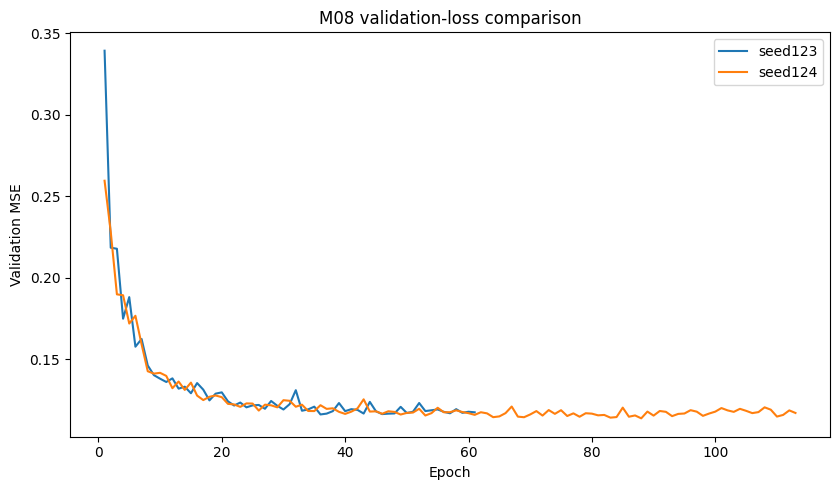

,run_id,best_epoch,stop_epoch,best_val_loss
0,seed123,36,61,0.116116
1,seed124,88,113,0.113727


In [29]:
def load_history(path):
    with np.load(path, allow_pickle=True) as data:
        return {key: np.asarray(data[key]) for key in data.files}

def first_existing(mapping, keys):
    for key in keys:
        if key in mapping:
            return np.asarray(mapping[key])
    return None

HISTORIES = {
    run_id: load_history(run["history_path"])
    for run_id, run in RUNS.items()
}

history_rows = []

plt.figure(figsize=(8.5, 5.0))

for run_id, history in HISTORIES.items():
    train_loss = first_existing(
        history, ["train_loss", "train_losses", "loss_train"]
    )
    val_loss = first_existing(
        history, ["val_loss", "val_losses", "loss_val"]
    )

    if train_loss is None or val_loss is None:
        print("Missing loss keys for", run_id)
        continue

    best_idx = int(np.nanargmin(val_loss))
    best_epoch = best_idx + 1

    history_rows.append({
        "run_id": run_id,
        "best_epoch": best_epoch,
        "stop_epoch": len(val_loss),
        "best_val_loss": val_loss[best_idx],
    })

    epochs = np.arange(1, len(val_loss) + 1)
    plt.plot(epochs, val_loss, label=run_id)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("M08 validation-loss comparison")
plt.legend()
plt.tight_layout()
plt.show()

history_summary_df = pd.DataFrame(history_rows)
display(history_summary_df)

## Checkpoint metadata sanity check

In [30]:
checkpoint_rows = []

try:
    import torch

    for run_id, run in RUNS.items():
        checkpoint = torch.load(run["checkpoint_path"], map_location="cpu")

        model_config = checkpoint.get("model_config", {})
        training_config = checkpoint.get("training_config", {})

        model_kwargs = (
            model_config.get("kwargs")
            or model_config.get("model_kwargs")
            or checkpoint.get("model_kwargs")
            or {}
        )

        checkpoint_rows.append({
            "run_id": run_id,
            "checkpoint_name": run["checkpoint_path"].name,
            "saved_epoch": checkpoint.get("epoch"),
            "best_val_loss": checkpoint.get("best_val_loss"),
            "training_seed": (
                training_config.get("training_seed")
                or checkpoint.get("training_seed")
            ),
            "split_seed": (
                training_config.get("split_seed")
                or checkpoint.get("split_seed")
            ),
            "dilations": model_kwargs.get("dilations"),
            "embedding_dim": model_kwargs.get("embedding_dim"),
            "residual_channels": model_kwargs.get("residual_channels"),
        })

    checkpoint_df = pd.DataFrame(checkpoint_rows)
    display(checkpoint_df)

    for _, row in checkpoint_df.iterrows():
        assert list(row["dilations"]) == [1, 2, 4]

except Exception as exc:
    print("Checkpoint inspection failed:", type(exc).__name__, exc)
    checkpoint_df = pd.DataFrame()

,run_id,checkpoint_name,saved_epoch,best_val_loss,training_seed,split_seed,dilations,embedding_dim,residual_channels
0,seed123,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,36,0.116116,None,None,"[1, 2, 4]",64,64
1,seed124,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,88,0.113727,None,None,"[1, 2, 4]",64,64


## Compact stability decision table

In [31]:
test_slope_pivot = (
    slope_df.query("split == 'test'")
    .pivot(index="label", columns="run_id")
)

decision_rows = []

for label in LABEL_NAMES:
    metric_row = seed_difference_df.set_index("label").loc[label]
    q95 = test_quantiles_df.query(
        "label == @label and quantile == 0.95"
    ).iloc[0]
    q99 = test_quantiles_df.query(
        "label == @label and quantile == 0.99"
    ).iloc[0]

    decision_rows.append({
        "label": label,
        "MSE_difference_pct": metric_row["MSE_difference_pct"],
        "MAE_difference_pct": metric_row["MAE_difference_pct"],
        "slope_seed123": test_slope_pivot.loc[
            label, ("slope", "seed123")
        ],
        "slope_seed124": test_slope_pivot.loc[
            label, ("slope", "seed124")
        ],
        "q95_difference_pct": q95["seed124_vs_seed123_pct"],
        "q99_difference_pct": q99["seed124_vs_seed123_pct"],
        "seed124_win_rate": win_rate_df.set_index("label").loc[
            label, "seed124_win_rate"
        ],
    })

decision_df = pd.DataFrame(decision_rows)

display(global_difference_df)
display(decision_df)

,global_MSE_seed123,global_MSE_seed124,global_MSE_difference_pct,global_MAE_seed123,global_MAE_seed124,global_MAE_difference_pct
0,0.116352,0.112170,-3.594568,0.244785,0.237502,-2.975626


,label,MSE_difference_pct,MAE_difference_pct,slope_seed123,slope_seed124,q95_difference_pct,q99_difference_pct,seed124_win_rate
0,chirp_mass,-1.813168,-3.098654,0.872785,0.891274,-0.080345,-0.946000,0.530600
1,total_mass,-2.647803,-2.757699,0.893434,0.904413,-0.514071,0.187928,0.519500
2,chi_eff,-4.875363,-3.030991,0.811833,0.801345,-2.381720,-0.062421,0.518367


## Save tables

In [32]:
OUTPUT_DIR = RESULTS_ROOT / "evaluation_M08_seed123_seed124"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "metrics_all.csv": metrics_df,
    "global_metrics.csv": global_metrics_df,
    "seed_differences_test.csv": seed_difference_df,
    "global_seed_difference_test.csv": global_difference_df,
    "slope_diagnostics.csv": slope_df,
    "absolute_error_quantiles.csv": quantiles_df,
    "win_rates_and_disagreement.csv": win_rate_df,
    "ensemble_metrics.csv": ensemble_metrics_df,
    "ensemble_global_metrics.csv": ensemble_global_df,
    "training_summary.csv": history_summary_df,
    "stability_decision_table.csv": decision_df,
}

if not checkpoint_df.empty:
    tables["checkpoint_metadata.csv"] = checkpoint_df

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/metrics_all.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/global_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/seed_differences_test.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/global_seed_difference_test.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/slope_diagnostics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/absolute_error_quantiles.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/win_rates_and_disagreement.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/ensemble_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/ensemble_global_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_seed123_seed124/training_summary.csv
Saved: /data/vserrano/cbc

## Final decision

### Validation stability

M08 shows consistent validation performance across the two independent training seeds. Seed123 reaches a best validation loss of 0.116116 at epoch 36, whereas seed124 reaches a slightly lower loss of 0.113727 at epoch 88. The relative difference is approximately 2.1% in favor of seed124.

The optimization trajectories differ substantially in convergence speed, but both runs reach the same performance regime. Seed123 converges faster, while seed124 continues improving for longer before reaching its best checkpoint. This indicates optimization variability in the convergence path, but not instability in the final solution quality.

### Test stability

The standardized global test MSE decreases from 0.116352 for seed123 to 0.112170 for seed124, corresponding to a 3.59% improvement. The global MAE decreases by 2.98%.

The result is consistent across all three targets. Seed124 reduces the MSE by 1.81% for chirp mass, 2.65% for total mass, and 4.88% for effective spin. The corresponding MAE reductions are approximately 3% for all targets.

The regression slopes for the mass parameters improve with seed124, increasing from 0.873 to 0.891 for chirp mass and from 0.893 to 0.904 for total mass. The effective-spin slope decreases slightly from 0.812 to 0.801, although its MSE, MAE, correlation, and q95 absolute-error quantile all improve. The q99 error quantiles remain nearly unchanged between seeds for all targets.

Seed124 produces lower absolute error than seed123 for slightly more than half of the test events for each target, indicating that its improvement is broadly distributed rather than being driven by a small number of extreme samples.

### Conclusion

The residual dilated M08 architecture is stable across the two independent training seeds. Both runs preserve the main scientific conclusions:

1. M08 remains substantially better than the original M00 baseline.
2. The residual dilated architecture consistently performs well across all three inferred parameters.
3. The performance differences between seeds are small relative to the improvement of M08 over M00.
4. A third seed is not necessary before proceeding with the conformal analysis.
5. Seed123 can remain the reference model for the controlled M00-versus-M08 Mondrian comparison because it was already used in the previous architectural ablations.
6. The seed123–seed124 ensemble provides an additional performance improvement, but it should remain an exploratory result unless it is explicitly adopted and recalibrated as a separate predictive system.

The next step is therefore to compare the conformal and Mondrian intervals obtained from M00 and M08 seed123 using identical calibration and test samples, confidence levels, interval modes, and binning configurations.
